Évaluation simple (Loss + Accuracy)

In [30]:
#fichier evalueate.py
from tensorflow.keras.models import load_model
import numpy as np
# Charger modèle entraîné
model = load_model("speech_model.keras")

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

# ⚠️ IMPORTANT : même normalisation que train
mean = np.load("../data/processed/X_train.npy").mean()
std = np.load("../data/processed/X_train.npy").std()

X_test = (X_test - mean) / std

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

662/662 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8833 - loss: 0.4428
Test Loss: 0.4428256154060364
Test Accuracy: 0.8832672238349915


Matrice de confusion + Rapport détaillé

In [39]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import load_model

# Charger le modèle (si pas déjà fait)
model = load_model("speech_model.keras")

# Charger ou utiliser X_test et y_test
# X_test.shape = (21168, 40, 44, 1)
# y_test.shape = (21168,)

# Faire les prédictions
y_pred_prob = model.predict(X_test)  # probabilités
y_pred = np.argmax(y_pred_prob, axis=1)  # classes prédites

# Accuracy globale
acc = accuracy_score(y_test, y_pred)
print("Accuracy globale :", acc)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Rapport de classification
report = classification_report(y_test, y_pred, zero_division=0)  # évite warnings
print("Classification Report:\n", report)

# Si tu veux aussi des métriques par classe en détail
num_classes = y_test.max() + 1
for i in range(num_classes):
    true_i = np.sum(y_test == i)
    pred_i = np.sum(y_pred == i)
    correct_i = np.sum((y_test == i) & (y_pred == i))
    print(f"Classe {i} : support={true_i}, prédits={pred_i}, corrects={correct_i}, recall={correct_i/true_i if true_i>0 else 0:.2f}")

662/662 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step
Accuracy globale : 0.8832671957671958
Confusion Matrix:
 [[  0   0   0 ...   0   0   0]
 [  0 296   2 ...   0   0   0]
 [  0   5 304 ...   0   2   0]
 ...
 [  0   2   0 ... 354   0   0]
 [  0   1   2 ...   1 750   4]
 [  0   1   0 ...   0   1 745]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.90      0.89      0.89       333
           2       0.88      0.75      0.81       403
           3       0.79      0.86      0.82       413
           4       0.91      0.89      0.90       406
           5       0.90      0.83      0.86       425
           6       0.88      0.88      0.88       783
           7       0.96      0.89      0.92       757
           8       0.87      0.90      0.88       811
           9       0.82      0.78      0.80       316
          10       0.83      0.66      0.73       311
          11       0.85      0.90  

In [ ]:
import numpy as np

# Charger X_train
X_train = np.load("../data/processed/X_train.npy")

# Calculer mean et std
mean = X_train.mean()
std = X_train.std()



print("Mean:", mean)
print("Std:", std)
print("Fichiers mean.npy et std.npy sauvegardés.")

Mean: 1.0595175e-07
Std: 1.0000017
Fichiers mean.npy et std.npy sauvegardés.


Courbe ROC (multi-classe)

662/662 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step


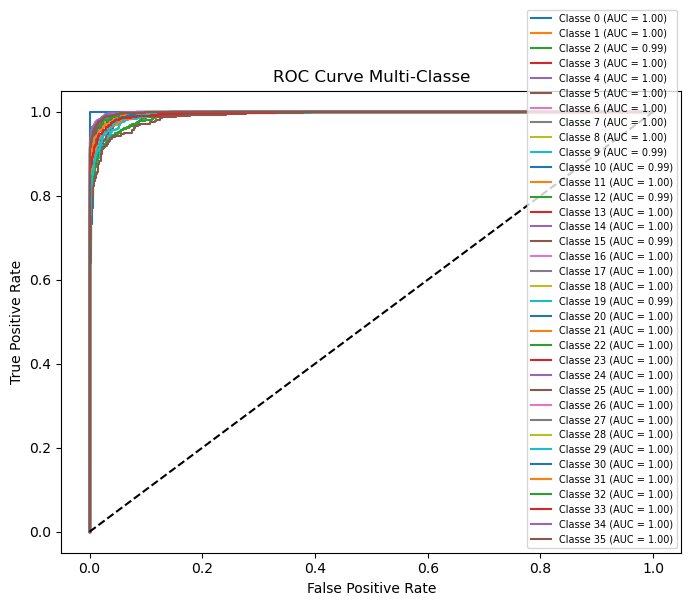

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model

# =========================
# 1️⃣ Charger le modèle
# =========================
model = load_model("speech_model.keras")

# =========================
# 2️⃣ Charger les données test
# =========================
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

# =========================
# 3️⃣ Charger mean et std
# =========================
mean = np.load("mean.npy")
std = np.load("std.npy")

X_test = (X_test - mean) / std

# =========================
# 4️⃣ Prédictions probabilités
# =========================
y_score = model.predict(X_test)

# =========================
# 5️⃣ Préparer y_test en one-hot
# =========================
n_classes = y_score.shape[1]
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# =========================
# 6️⃣ Tracer ROC par classe
# =========================
plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {i} (AUC = {roc_auc:.2f})")

# Ligne aléatoire
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Multi-Classe")
plt.legend(loc="lower right", fontsize=7)
plt.show()

In [38]:
print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

# Vérifier si test = train
X_train = np.load("../data/processed/X_train.npy")

print("Train shape:", X_train.shape)

# Comparaison rapide
print("Test identique au Train ? ", np.array_equal(X_test, X_train))

Shape X_test: (21168, 40, 44, 1)
Shape y_test: (21168,)
Train shape: (74084, 40, 44, 1)
Test identique au Train ?  False


Visualiser l’overfitting (très important)

2316/2316 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Train Accuracy: 0.9385, Train Loss: 0.2066
Val Accuracy: 0.8888, Val Loss: 0.4600


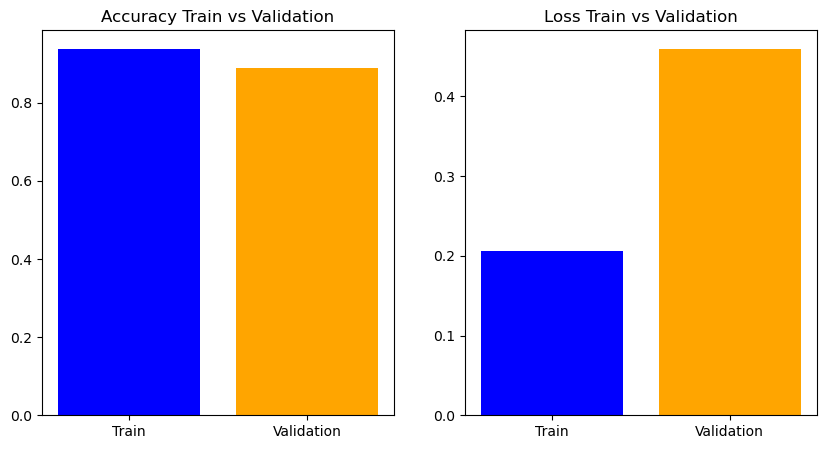

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, log_loss

# Charger modèle entraîné
model = load_model("speech_model.keras")

# Charger données
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")
X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

# Normalisation (comme à l'entraînement)
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean)/std
X_val = (X_val - mean)/std

# Faire des prédictions probabilistes
y_train_pred_prob = model.predict(X_train, batch_size=32)
y_val_pred_prob = model.predict(X_val, batch_size=32)

# Accuracy
y_train_pred = np.argmax(y_train_pred_prob, axis=1)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

# Loss (log loss)
train_loss = log_loss(y_train, y_train_pred_prob, labels=np.arange(36))
val_loss = log_loss(y_val, y_val_pred_prob, labels=np.arange(36))

print(f"Train Accuracy: {train_acc:.4f}, Train Loss: {train_loss:.4f}")
print(f"Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

# Tracer un "overfitting snapshot"
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(['Train','Validation'], [train_acc, val_acc], color=['blue','orange'])
plt.title("Accuracy Train vs Validation")

plt.subplot(1,2,2)
plt.bar(['Train','Validation'], [train_loss, val_loss], color=['blue','orange'])
plt.title("Loss Train vs Validation")
plt.show()